<a href="https://colab.research.google.com/github/Olya-Shulga/Univercity/blob/main/Tasks/%D0%94%D0%9F%D0%9E_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D1%80%D0%B0%D1%81%D1%82%D1%80%D0%BE%D0%B2%D1%8B%D0%BC%D0%B8_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8_%D0%B2_Rasterio_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №3. Работа с растровыми данными в Rasterio**

---

**Данные для обработки:**

- Одноканальное изображение (ЦМР): https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
- Мультиспектральное изображение (Landsat): https://github.com/opengeos/datasets/releases/download/raster/cog.tif

### **Задание 1. Чтение и исследование растровых данных**



1. Откройте одноканальное изображение ЦМР с использованием `rasterio`.


In [1]:
%%capture
%pip install rasterio fiona folium matplotlib mapclassify

In [2]:
import rasterio
import rasterio.plot
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
raster_path = (
    "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
)

src = rasterio.open(raster_path)

print(src)

<open DatasetReader name='https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif' mode='r'>


2. Извлеките и выведите метаданные растра, включая СК, разрешение, границы, количество каналов и типы данных.


In [4]:
src.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': None,
 'width': 4269,
 'height': 3113,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'),
 'transform': Affine(90.0, 0.0, -13442488.3428,
        0.0, -89.99579177642138, 4668371.5775)}

3. Отобразите ширину и высоту растра, а также типы данных пикселей, чтобы понять размеры сетки и структуру данных.

In [6]:
print(f"Ширина: {src.width}")

Ширина: 4269


In [7]:
print(f"Высота: {src.height}")

Высота: 3113


In [8]:
print(f"Тип данных: {src.dtypes}")


Тип данных: ('int16',)


---



### **Задание 2. Визуализация и манипулирование растровыми каналами**



1. Визуализируйте одноканальное изображение ЦМР с использованием пользовательской цветовой карты (например, cmap='terrain').


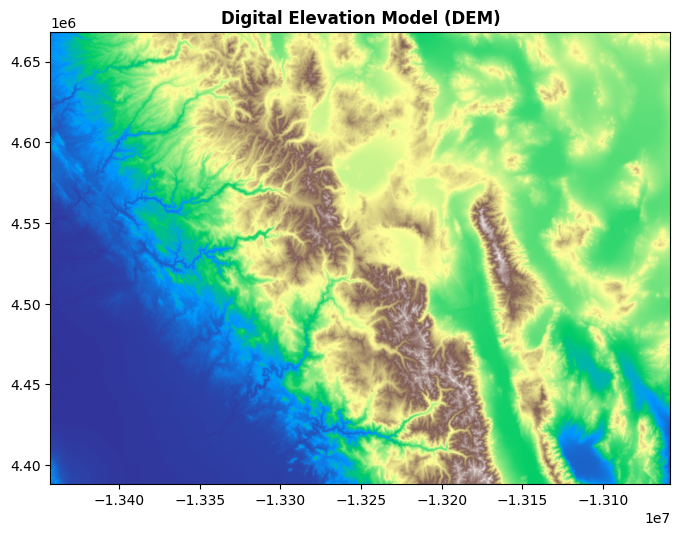

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

rasterio.plot.show(src, cmap="terrain", ax=ax, title="Digital Elevation Model (DEM)")

plt.show()

2. Откройте мультиспектральное изображение и визуализируйте первый канал с использованием подходящей цветовой карты.


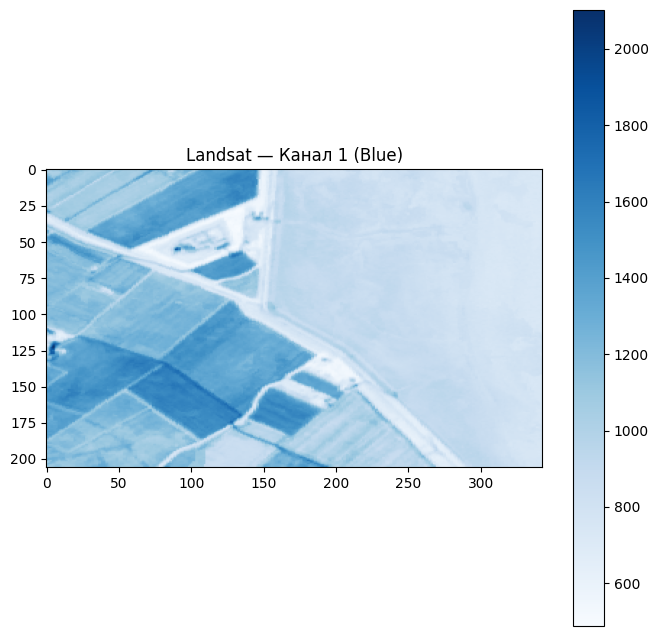

In [17]:
landsat_path = "https://github.com/opengeos/datasets/releases/download/raster/cog.tif"

src_landsat = rasterio.open(landsat_path)
band1 = src_landsat.read(1)

# Визуализация
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(band1, cmap='Blues')
ax.set_title("Landsat — Канал 1 (Blue)")
plt.colorbar(im, ax=ax)
plt.show()

3. Объедините несколько каналов из мультиспектрального изображения (например, Красный, Зеленый и Синий) и совместите их в один массив для создания RGB-композитного изображения.

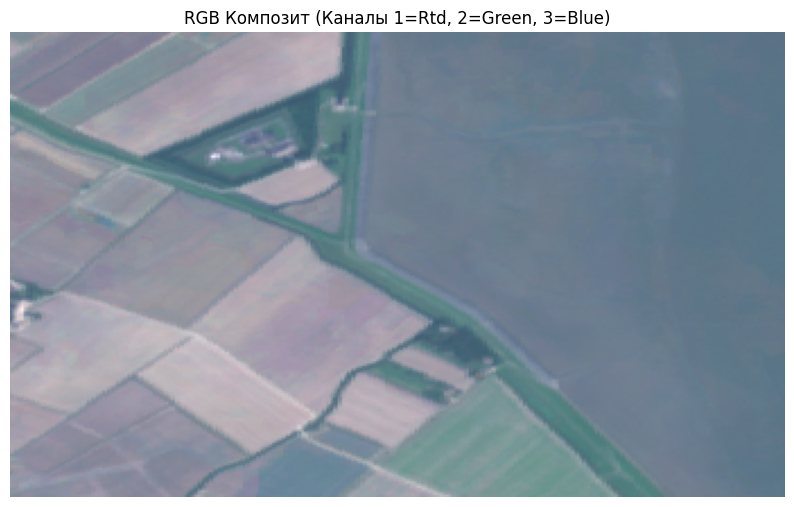

In [19]:
rgb_bands = src_landsat.read([1, 2, 3])
rgb_image = rasterio.plot.reshape_as_image(rgb_bands)

rgb_normalized = np.clip(rgb_image / rgb_image.max(), 0, 1)

# Визуализация
plt.figure(figsize=(10, 10))
plt.imshow(rgb_normalized)
plt.axis('off')
plt.title("RGB Композит (Каналы 1=Rtd, 2=Green, 3=Blue)")
plt.show()

---



### **Задание 3. Обрезка растра с использованием индексации массива**



1. Откройте мультиспектральное изображение и обрежьте его с использованием спискового среза (указав диапазоны строк и столбцов).


In [28]:
landsat_path = "https://github.com/opengeos/datasets/releases/download/raster/cog.tif"

with rasterio.open(landsat_path) as src:
    full_data = src.read()  # shape: (каналы, высота, ширина)

# Задаём диапазоны строк и столбцов для обрезки
row_start, row_end = 100, 900   # 800 пикселей по высоте
col_start, col_end = 100, 900   # 800 пикселей по ширине

# Обрезаем изображение с помощью спискового среза
cropped_data = full_data[:, row_start:row_end, col_start:col_end]

2. Визуализируйте обрезанную часть изображения с использованием matplotlib, чтобы убедиться в корректном результате.


>*Примечание:*
>
> При работе с многоканальными растровыми изображениями, особенно в формате COG.TIFF (Cloud Optimized GeoTIFF), может возникнуть проблема с некорректным отображением псевдоцветного изображения. Это связано с тем, что разные каналы могут иметь различные диапазоны значений пикселей.
>
> Для корректной визуализации на шаге 2 необходимо применить нормализацию к каждому каналу перед отображением.



Включите следующую функцию в ваш код:

```python
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm
```

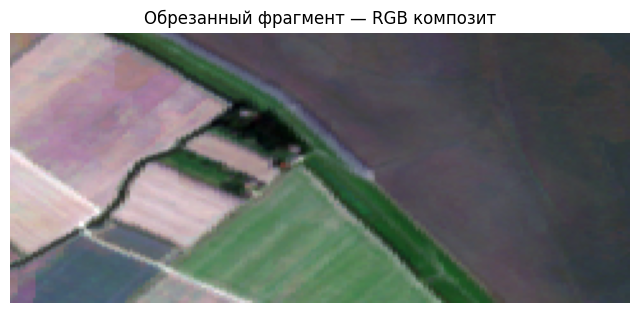

In [29]:
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    if band_max - band_min == 0:
        return np.zeros_like(band)
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm

# Визуализация RGB-композита (первые 3 канала)
if cropped_data.shape[0] >= 3:
    r = normalize(cropped_data[0])
    g = normalize(cropped_data[1])
    b = normalize(cropped_data[2])
    rgb = np.stack([r, g, b], axis=-1)

    plt.figure(figsize=(8, 8))
    plt.imshow(rgb)
    plt.title("Обрезанный фрагмент — RGB композит")
    plt.axis('off')
    plt.show()

3. Сохраните обрезанное подмножество растра в новый файл с именем `clipped_multispectral.tif`.

In [30]:
# Открываем исходный файл ещё раз, чтобы получить метаданные И transform
landsat_path = "https://github.com/opengeos/datasets/releases/download/raster/cog.tif"

with rasterio.open(landsat_path) as src_landsat:
    # Получаем исходные метаданные
    meta = src_landsat.meta.copy()

    # Исходная геотрансформация
    transform = src_landsat.transform

    # Новая геотрансформация для обрезанного фрагмента
    new_transform = rasterio.transform.Affine.translation(
        col_start * transform.a,  # x-смещение (столбцы)
        row_start * transform.e   # y-смещение (строки, transform.e — отрицательное)
    ) * transform

    # Обновляем метаданные
    meta.update({
        'height': cropped_data.shape[1],   # строки
        'width': cropped_data.shape[2],    # столбцы
        'transform': new_transform
    })

    # Сохраняем обрезанный растр
    with rasterio.open('clipped_multispectral.tif', 'w', **meta) as dst:
        dst.write(cropped_data)

---



### **Задание 4. Вычисление NDWI (калькуляция каналов)**



1. Откройте мультиспектральное изображение и извлеките каналы Green (Зеленый) и Ближний инфракрасный (NIR).


In [33]:
landsat_path = "https://github.com/opengeos/datasets/releases/download/raster/cog.tif"

with rasterio.open(landsat_path) as src:
    # Извлекаем канал 2 (Green) и канал 4 (NIR)
    green_band = src.read(2)   # Зелёный канал
    nir_band = src.read(4)     # Ближний инфракрасный канал

print("Форма зелёного канала:", green_band.shape)
print("Форма NIR канала:", nir_band.shape)

Форма зелёного канала: (206, 343)
Форма NIR канала: (206, 343)


2. Вычислите Нормализованный разностный водный индекс ([NDWI](https://en.wikipedia.org/wiki/Normalized_difference_water_index)) по формуле:

    NDWI = (Green - NIR) / (Green + NIR)

/tmp/ipython-input-3474918129.py:7: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 4 Axes> than <Figure size 1000x800 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(im, label='NDWI')


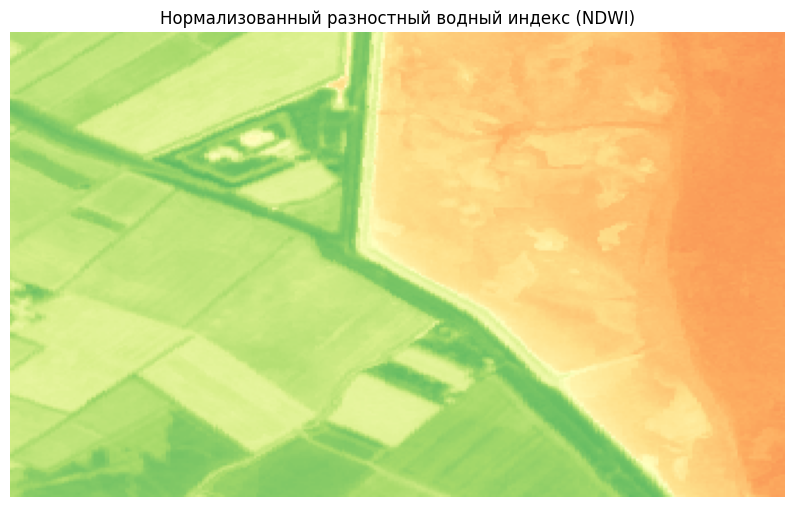

In [35]:
ndvi = (nir_band - green_band) / (nir_band + green_band)
ndvi = ndvi.clip(-1, 1)


plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, label='NDWI')
plt.title('Нормализованный разностный водный индекс (NDWI)')
plt.axis('off')
plt.show()


3. Визуализируйте результат NDWI с использованием цветовой карты, подходящей для воды (например, cmap='Blues'), чтобы выделить водные объекты.


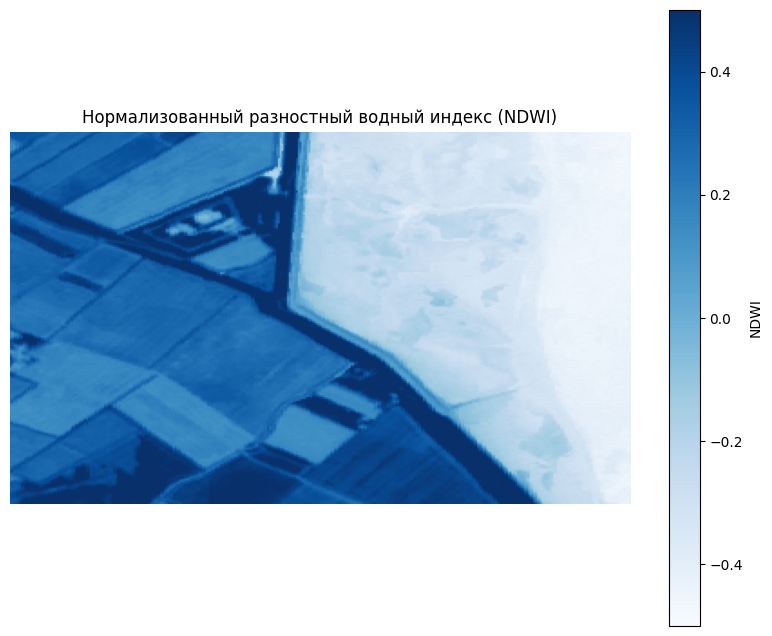

In [37]:
plt.figure(figsize=(10, 8))
im = plt.imshow(ndvi, cmap='Blues', vmin=-0.5, vmax=0.5)
plt.colorbar(im, label='NDWI')
plt.title('Нормализованный разностный водный индекс (NDWI)')
plt.axis('off')
plt.show()



4. Сохраните полученное изображение NDWI как новый растровый файл с именем ndwi.tif.

In [38]:
with rasterio.open(landsat_path) as src:
    # Создаём копию метаданных
    meta = src.meta.copy()

    # Обновляем метаданные для одноканального изображения
    meta.update({
        'count': 1,
        'dtype': 'float32',
        'compress': 'lzw'
    })

    # Сохраняем NDWI в новый файл
    with rasterio.open('ndwi.tif', 'w', **meta) as dst:
        dst.write(ndvi, 1)

print("Файл 'ndwi.tif' успешно сохранён!")

Файл 'ndwi.tif' успешно сохранён!


---



### **Задание 5. Перепроецирование растровых данных**



1. Перепроецируйте одноканальный растр ЦМР из его исходной СК в EPSG:4326 (WGS 84) с использованием функции `rasterio.warp.reproject`.


In [39]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

raster_path = "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
dst_crs = "EPSG:3857"

with rasterio.open(raster_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    # Сохраняем исходные данные и параметры для следующих шагов
    src_profile = src.profile.copy()
    src_data = src.read(1).astype('float32')
    src_transform = src.transform
    src_crs = src.crs

# Создаём пустой массив для перепроецированного растра
reprojected_data = np.empty((height, width), dtype='float32')

# Выполняем перепроецирование
reproject(
    source=src_data,
    destination=reprojected_data,
    src_transform=src_transform,
    src_crs=src_crs,
    dst_transform=transform,
    dst_crs=dst_crs,
    resampling=Resampling.nearest
)

(array([[ 579.,  582.,  591., ..., 2014., 2029., 2040.],
        [ 595.,  603.,  613., ..., 1986., 1995., 2010.],
        [ 609.,  622.,  628., ..., 1964., 1987., 2011.],
        ...,
        [ 544.,  541.,  569., ...,  451.,  446.,  440.],
        [ 530.,  532.,  566., ...,  455.,  446.,  437.],
        [ 520.,  519.,  544., ...,  447.,  450.,  447.]], dtype=float32),
 Affine(90.0, 0.0, -13442488.3428,
        0.0, -89.99579177642138, 4668371.5775))

2. Сохраните перепроецированный растр в новый файл GeoTIFF с именем `reprojected_dem.tif`.


In [40]:
profile = src_profile
profile.update({
    'crs': dst_crs,
    'transform': transform,
    'width': width,
    'height': height,
    'dtype': 'float32',
    'count': 1
})

# Записываем перепроецированный растр в файл
with rasterio.open('reprojected_dem.tif', 'w', **profile) as dst:
    dst.write(reprojected_data, 1)

print("Перепроецированный ЦМР сохранён как: reprojected_dem.tif")

Перепроецированный ЦМР сохранён как: reprojected_dem.tif


3. Визуализируйте как исходный, так и перепроецированный наборы данных ЦМР, чтобы сравнить, как перепроецирование влияет на пространственное покрытие и разрешение.

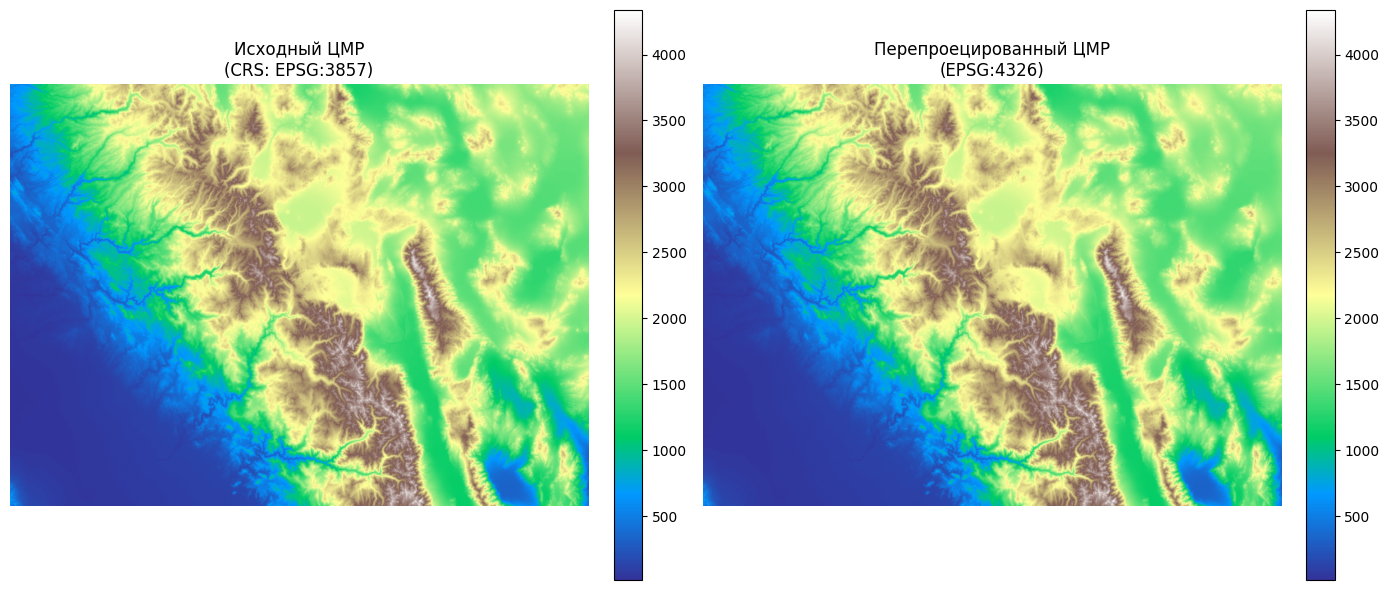

Исходное разрешение: (3113, 4269) пикселей
После перепроецирования: (3113, 4269) пикселей
Исходные границы: BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)
Границы в EPSG:4326: BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)


In [41]:
# Читаем исходный ЦМР снова для визуализации
with rasterio.open(raster_path) as src_orig:
    orig_data = src_orig.read(1)
    orig_bounds = src_orig.bounds

# Читаем перепроецированный ЦМР
with rasterio.open('reprojected_dem.tif') as src_repr:
    repr_data = src_repr.read(1)
    repr_bounds = src_repr.bounds

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Исходный ЦМР
im1 = axes[0].imshow(orig_data, cmap='terrain')
axes[0].set_title('Исходный ЦМР\n(CRS: {})'.format(rasterio.open(raster_path).crs))
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Перепроецированный ЦМР
im2 = axes[1].imshow(repr_data, cmap='terrain')
axes[1].set_title('Перепроецированный ЦМР\n(EPSG:4326)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Дополнительно: выведем информацию о размерах
print(f"Исходное разрешение: {orig_data.shape} пикселей")
print(f"После перепроецирования: {repr_data.shape} пикселей")
print(f"Исходные границы: {orig_bounds}")
print(f"Границы в EPSG:4326: {repr_bounds}")

---